In [1]:
using BSON: @load
using CSV
using Dates
using DriftDiffusionModels
using HiddenMarkovModels
using MultivariateStats
using LinearAlgebra
using Clustering
using DataFrames
using HypothesisTests
using Distances
using Random
using StatsBase
using StatsPlots
using PlotUtils
using Plots
using Turing
using MCMCChains
using CategoricalArrays
using Base.Threads: @threads
using CairoMakie

In [2]:
# set data dirtectory
data_dir = joinpath(@__DIR__, "..", "data")

# read out all BSOn files that have a 4 in them (K=4)
bson_files = filter(f -> occursin("K4", f), readdir(data_dir; join=true))
bson_files = filter(f -> occursin("daily", f), bson_files) # only keep daily files

# read all data into a bson file. We need to define the following struct for it to work right.
struct DDMHMMFit
    hmm::PriorHMM
    logL::Float64
    logL_evolution::Vector{Float64}
end

ddmhmm_fits = DDMHMMFit[]  

for bson_file in bson_files
    @load bson_file fit   # defines `fit` in this scope
    push!(ddmhmm_fits, fit)
end

In [13]:
# compute a grand average ACF across all rats
real_data = CSV.read(joinpath(@__DIR__, "..", "data", "processed_rat_data.csv.gz"), DataFrame)
real_data = real_data[real_data.daily .== "daily", :] # only keep 24 hour data

names = ["Daenerys", "Dobby", "Dory", "Regina", "Rhubarb", "1034"] 
real_data = real_data[in.(real_data.name, Ref(names)), :]

# preprocess the data to have numerics
replace!(real_data[!, :choose_right], 0 => -1)

mapping = Dict("right" => 1, "left" => -1)
DataFrames.transform!(real_data, :correct_side => ByRow(cs -> get(mapping, cs, missing)) => :correct_side_numeric)

mean_acfs = Vector{Float64}[]
function compute_acf_from_df!(df::DataFrame, name::String)
    rat_of_interest = df[df.name .== name, :]

    dates = [Date(split(dt)[1]) for dt in rat_of_interest.trial_datetime]
	
    # Get unique dates in chronological order
    unique_dates = sort(unique(dates))
        
    # Create a vector of vectors, where each inner vector contains DDMResults for one day
    results_by_date = Vector{Vector{DDMResult}}()

    for date in unique_dates
        # Get indices for this date
        day_indices = findall(dates .== date)

        # Skip days with no valid data
        if isempty(day_indices)
            continue
        end

        # Extract RTs and outcomes for this date
        day_rts = rat_of_interest.rt[day_indices]
        day_outcomes = rat_of_interest.choose_right[day_indices]
        day_stim_side = rat_of_interest.correct_side_numeric[day_indices]
            
        # Create DDMResult objects for this day
        day_results = [DDMResult(rt, choice, stim) for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]
        
        # Add to our vector of vectors
        push!(results_by_date, day_results)
    end 

    rt_acfs = Vector{Vector{Float64}}()
    for day in results_by_date
        rts = [res.rt for res in day]
        acf = autocor(rts, 1:20)
        push!(rt_acfs, acf)
    end

    average_acf = mean(reduce(hcat, rt_acfs); dims=2)[:, 1]
    push!(mean_acfs, average_acf)
end

for name in names
    compute_acf_from_df!(real_data, name)
end

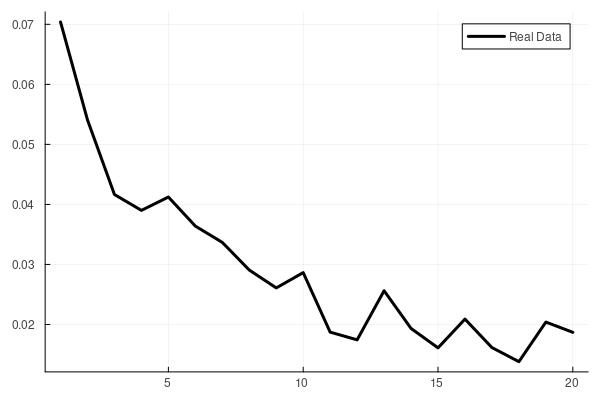

In [ ]:
grand_average_acf = mean(reduce(hcat, mean_acfs); dims=2)[:, 1]



In [9]:
function mean_acf_over_mice(hmms::Vector; n_tsteps::Int, lags=1:20, burn::Int=0)
    n_mice = length(hmms)
    A = Matrix{Float64}(undef, length(lags), n_mice)

    for (j, hmm) in enumerate(hmms)
        s, o = rand(hmm, n_tsteps + burn)
        rts = [res.rt for res in o]
        if burn > 0
            rts = rts[(burn+1):end]
        end
        A[:, j] = autocor(rts, lags)
    end

    return vec(mean(A; dims=2))  # length(lags)
end

function ppc_population_acf(hmms::Vector; n_rep::Int=500, n_tsteps::Int=1000, lags=1:20, burn::Int=0)
    reps = Vector{Vector{Float64}}(undef, n_rep)
    for r in 1:n_rep
        reps[r] = mean_acf_over_mice(hmms; n_tsteps=n_tsteps, lags=lags, burn=burn)
    end

    M = reduce(hcat, reps)  # (n_lags × n_rep)

    pred_mean = vec(mean(M; dims=2))
    lo = [quantile(view(M, i, :), 0.025) for i in 1:size(M, 1)]
    hi = [quantile(view(M, i, :), 0.975) for i in 1:size(M, 1)]
    return pred_mean, lo, hi, M
end

hmms = [fits.hmm for fits in ddmhmm_fits]  # should be length 6
pred_mean, lo, hi, M = ppc_population_acf(hmms; n_rep=100, n_tsteps=1000)

([0.10182665040035042, 0.06111411448669788, 0.040174757462586023, 0.035498904917296084, 0.028022673929750944, 0.020298695874537632, 0.017645757314861298, 0.01373204501990507, 0.015074484648601984, 0.00841263676706154, 0.007994241881702767, 0.008875055295633314, 0.006702894656089761, 0.00556346346192729, 0.0042521174731668405, 0.0040809488379813215, 0.004484461538049778, 0.0034012718923183255, 0.0012254055782970846, 0.0034982126258400726], [0.057574908851028214, 0.018034420335538183, 0.003840050167252704, 0.011642093413812005, -0.003311588058174126, -0.011548626586862922, -0.009233639072682452, -0.014725390793201874, -0.011498506768014111, -0.018030127266208906, -0.015546705555089364, -0.014173477133067413, -0.014870709948068411, -0.024853694718248505, -0.02064954265550288, -0.023581719538072168, -0.01747554768153268, -0.02156575796952213, -0.02533839608222753, -0.025156104525066947], [0.15660688735769623, 0.10963366277046496, 0.07716848583754364, 0.06800865197785275, 0.0578086598866130

In [23]:

acf_ppc = Plots.plot(pred_mean, ribbon=(pred_mean - lo, hi - pred_mean), label="DDM-HMM PPC", alpha=0.5, linewidth=3, fontfamily="helvetica")
acf_ppc = Plots.plot!(grand_average_acf, label="Real Data", color=:black, linewidth=3, fontfamily="helvetica")
Plots.xlabel!("Lag")
Plots.ylabel!("ACF")
savefig(acf_ppc, joinpath(@__DIR__, "..", "rat_daily_acf_ppc.svg"))

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\rat_daily_acf_ppc.svg"

In [36]:
# plot example RT histogram for one of the rats
rat_of_interest = real_data[real_data.name .== "Dobby", :]

# simulate data from dobby 
dobby_hmm = ddmhmm_fits[2].hmm  # Dobby is the second one in the list

s, o = rand(dobby_hmm, 20000)
dobby_rts = [res.rt for res in o]

# QUICK KERNEL DENSITY ESTIMATE FROM SCRATCh
function kde(x::Vector{Float64}; bandwidth::Float64=0.05, n_points::Int=1000)
    x_min, x_max = minimum(x), maximum(x)
    x_grid = range(x_min - 3*bandwidth, x_max + 3*bandwidth, length=n_points)
    density = zeros(length(x_grid))

    for xi in x
        density .+= exp.(-0.5 * ((x_grid .- xi) ./ bandwidth).^2) ./ (bandwidth * sqrt(2π))
    end

    return x_grid, density ./ length(x)
end

x_grid, density = kde(dobby_rts; bandwidth=0.05, n_points=1000)

(-0.047067999999917745:0.007583886887565033:7.52923500067755, [7.140364241771971e-6, 1.1499085218914773e-5, 1.8143760815442987e-5, 2.8055412641607764e-5, 4.2525174559545994e-5, 6.32035557988408e-5, 9.213830717313184e-5, 0.00013179264852819438, 0.0001850353197078906, 0.00025509469169564687  …  0.00010483285516682417, 8.087349424141141e-5, 6.0971035493960055e-5, 4.4921008712884e-5, 3.234327496866819e-5, 2.275763088252066e-5, 1.5648714521521394e-5, 1.0515716007838833e-5, 6.905698161848667e-6, 4.431848412839927e-6])

In [40]:

histogram(rat_of_interest.rt, bins=100, label="True RTs", fontfamily="helvetica", normalize=:pdf)
Plots.plot!(x_grid, density, lw=3,label="DDM-HMM Simulation", fontfamily="helvetica")
Plots.xlabel!("RT (s)")
Plots.ylabel!("Density")
title!("Example 2-Hour RT Distribution")


savefig(joinpath(@__DIR__, "..", "rat_daily_example_rt_histogram.svg"))

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\rat_daily_example_rt_histogram.svg"

In [61]:
# example posteriors for a rat
rat_of_interest = real_data[real_data.name .== "Dobby", :]

dates = [Date(split(dt)[1]) for dt in rat_of_interest.trial_datetime]
	
# Get unique dates in chronological order
unique_dates = sort(unique(dates))
        
# Create a vector of vectors, where each inner vector contains DDMResults for one day
results_by_date = Vector{Vector{DDMResult}}()

for date in unique_dates
    # Get indices for this date
    day_indices = findall(dates .== date)

    # Skip days with no valid data
    if isempty(day_indices)
        continue
    end

    # Extract RTs and outcomes for this date
    day_rts = rat_of_interest.rt[day_indices]
    day_outcomes = rat_of_interest.choose_right[day_indices]
    day_stim_side = rat_of_interest.correct_side_numeric[day_indices]
            
    # Create DDMResult objects for this day
    day_results = [DDMResult(rt, choice, stim) for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]
        
    # Add to our vector of vectors
    push!(results_by_date, day_results)
end 

all_results = vcat(results_by_date...)  # flatten to all results
seq_ends = cumsum(length.(results_by_date))  # sequence ends for HMM

result_1 = results_by_date[3]

gamma, _ = forward_backward(ddmhmm_fits[2].hmm, result_1)

([3.6601072282451074e-17 1.1049569332516232e-6 … 0.18984570580612747 0.19370512185502245; 0.7871245776815204 0.8341045913665341 … 0.74358961817541 0.734626593121181; 0.20529487281573414 0.16438214125750536 … 0.06554354228710517 0.07035498417447797; 0.007580549502745827 0.001512162419027638 … 0.0010211337313574618 0.0013133008493186747], [-146.79220345693216])

In [56]:
post_plot = Plots.plot(gamma[1, :], label="State 1", lw=3, fontfamily="helvetica", legend=false)
Plots.plot!(gamma[2, :], label="State 2", lw=3, fontfamily="helvetica")
Plots.plot!(gamma[3, :], label="State 3", lw=3, fontfamily="helvetica")
Plots.plot!(gamma[4, :], label="State 4", lw=3, fontfamily="helvetica")
Plots.ylabel!("Posterior Probability")
Plots.xlabel!("Trial")
savefig(joinpath(@__DIR__, "..", "rat_daily_example_posterior.svg"))


"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\rat_daily_example_posterior.svg"

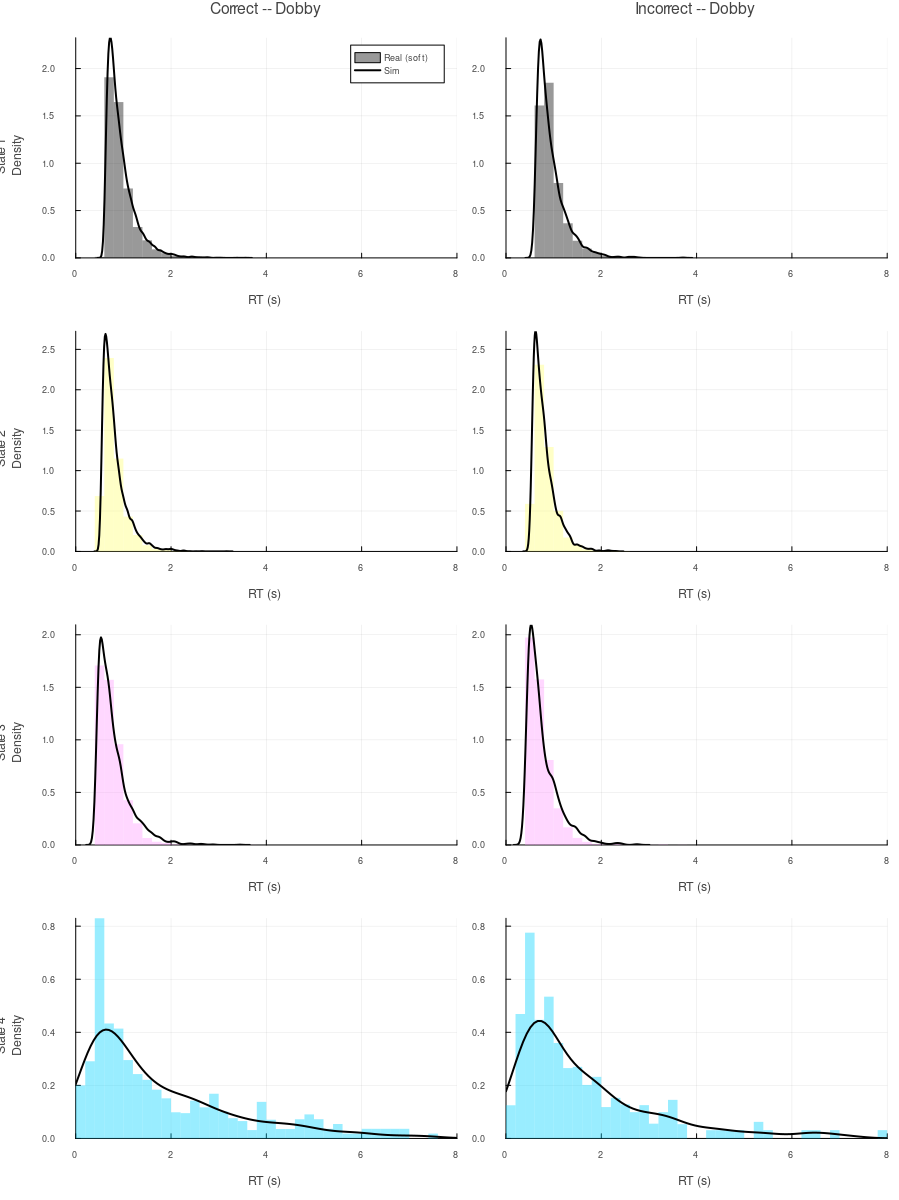

In [68]:
# RT hists
rat_str = "Dobby"

γ, _ = forward_backward(ddmhmm_fits[2].hmm, all_results; seq_ends=seq_ends)

K, T = size(γ)
@assert length(all_results) == T "γ and all_results must have same length"

# basic trial info 
rts        = [res.rt for res in all_results]
is_correct = [res.choice == res.s for res in all_results]

# Use *index vectors* instead of Bool masks for indexing
correct_idx   = findall(is_correct)
incorrect_idx = findall(.!is_correct)

# soft RT dists
n_sims = 30000

simulated_rts = Dict{Int, Dict{String, Vector{Float64}}}()

states, data = rand(ddmhmm_fits[2].hmm, n_sims)

for s in 1:K
    simulated_rts[s] = Dict("correct" => Float64[], "incorrect" => Float64[])
    state_s_trials = findall(x -> x == s, states)
    for trial_idx in state_s_trials
        res = data[trial_idx]
        local is_correct = (res.choice == res.s)
        category = is_correct ? "correct" : "incorrect"
        push!(simulated_rts[s][category], res.rt)
    end
end

state_colors = distinguishable_colors(K)

# layout: K rows × 2 columns (Correct / Incorrect)
pA = Plots.plot(layout = (K, 2),
          size   = (900, 300*K),
          link   = :x,
          fontfamily = "helvetica")

for s in 1:K
    idx_correct   = 2*(s-1) + 1
    idx_incorrect = 2*(s-1) + 2

    γs = vec(γ[s, :])   # length T

    # Correct
    rts_c = rts[correct_idx]
    w_c   = γs[correct_idx]

    if !isempty(rts_c)
        histogram!(pA[idx_correct],
                   rts_c;
                   weights   = w_c,
                   bins      = 50,
                   normalize = :pdf,
                   fillalpha = 0.4,
                   linealpha = 0.0,
                   color     = state_colors[s],
                   label     = s == 1 ? "Real (soft)" : "")
    end

    sim_rts_c = get(simulated_rts[s], "correct", Float64[])
    if !isempty(sim_rts_c)
        StatsPlots.density!(pA[idx_correct],
                 sim_rts_c;
                 linewidth = 2,
                 color     = :black,
                 label     = s == 1 ? "Sim" : "")
    end

    Plots.plot!(pA[idx_correct];
          xlabel = "RT (s)",
          ylabel = "State $s\nDensity",
          title  = s == 1 ? "Correct -- $rat_str" : "",
          legend = (s == 1))

    # Incorrect 
    rts_i = rts[incorrect_idx]
    w_i   = γs[incorrect_idx]

    if !isempty(rts_i)
        histogram!(pA[idx_incorrect],
                   rts_i;
                   weights   = w_i,
                   bins      = 50,
                   normalize = :pdf,
                   fillalpha = 0.4,
                   linealpha = 0.0,
                   color     = state_colors[s],
                   label     = "")
    end

    sim_rts_i = get(simulated_rts[s], "incorrect", Float64[])
    if !isempty(sim_rts_i)
        StatsPlots.density!(pA[idx_incorrect],
                 sim_rts_i;
                 linewidth = 2,
                 color     = :black,
                 label     = "")
    end

    Plots.plot!(pA[idx_incorrect];
          xlabel = "RT (s)",
          ylabel = "",
          title  = s == 1 ? "Incorrect -- $rat_str" : "",
          legend = false)
end

for s in 1:K
    idx_correct   = 2*(s-1) + 1
    idx_incorrect = 2*(s-1) + 2

    # current y-lims for that row's two plots
    y1_min, y1_max = Plots.ylims(pA[idx_correct])
    y2_min, y2_max = Plots.ylims(pA[idx_incorrect])

    # choose a common y-range for the row
    row_min = min(y1_min, y2_min)
    row_max = max(y1_max, y2_max)

    # apply the same y-lims to both panels in that row
    Plots.ylims!(pA[idx_correct],   row_min, row_max)
    Plots.ylims!(pA[idx_incorrect], row_min, row_max)
end

Plots.xlims!(0, 8)

display(pA)

In [69]:
savefig(pA, joinpath(@__DIR__, "..", "rat_daily_rt_distributions.svg"))

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\rat_daily_rt_distributions.svg"